In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Metadata analysis

In [2]:
metadata = pd.read_csv('D:\Developer\EEG Dataset\ds003670\participants.tsv', sep='\t', header=0)
metadata

,participant_id,gender,age,Height,Weight,Ethnicity,Race,Education,Handedness,Language,Prof,Exercise,Exercisehours,Stim,RepeatParticipants,ParticipantNote
0,sub-001,M,43,187.96,97.5200,Non-Hispanic/Latino,White/Caucasian,21,right,no,Native/Bilingual,no,-,yes,-,-
1,sub-002,M,40,180.33,79.3900,Non-Hispanic/Latino,Asian,30,right,yes,Native/Bilingual,yes,5,yes,-,-
2,sub-003,M,31,172.72,70.3000,Non-Hispanic/Latino,Asian,16,left,no,Advanced,yes,8,yes,-,-
3,sub-004,M,33,165.10,64.8600,Non-Hispanic/Latino,White/Caucasian,18,right,no,Intermediate,no,-,yes,-,-
4,sub-005,F,32,165.00,63.0000,Non-Hispanic/Latino,White/Caucasian,25,left,no,Advanced,no,-,yes,-,-
5,sub-006,M,31,167.64,63.5000,Non-Hispanic/Latino,Asian,23,right,no,Bilingual,yes,2,yes,-,-
6,sub-007,F,20,154.94,54.4311,Non-Hispanic/Latino,Asian,14,right,no,Advanced,no,-,no,-,-
7,sub-008,M,22,170.18,77.1100,Hispanic/Latino,White/Caucasian,17,left,yes,Advanced,yes,2,yes,-,-
8,sub-009,F,19,154.94,47.6300,Non-Hispanic/Latino,Asian,14,right,yes,-,no,-,no,-,-
9,sub-010,M,22,187.96,86.1800,Hispanic/Latino,-,15,right,no,Advanced,yes,6,no,-,-


In [3]:
CATEG = ["gender", "Ethnicity", "Race", "Handedness", "Language", "Prof", "Exercise", "Stim"]
NUM = ["age", "Height", "Weight", "Education", "Exercisehours"]

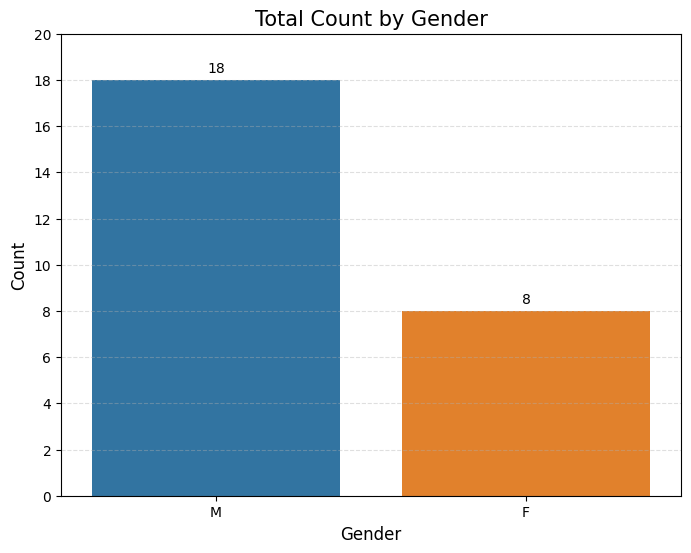

In [4]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=metadata, x='gender', hue='gender')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='400')

# Adding descriptive labels
plt.title('Total Count by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.4, axis="y", linestyle='--')
plt.yticks(range(0, 21, 2))
plt.ylim(0, 20)
plt.show()

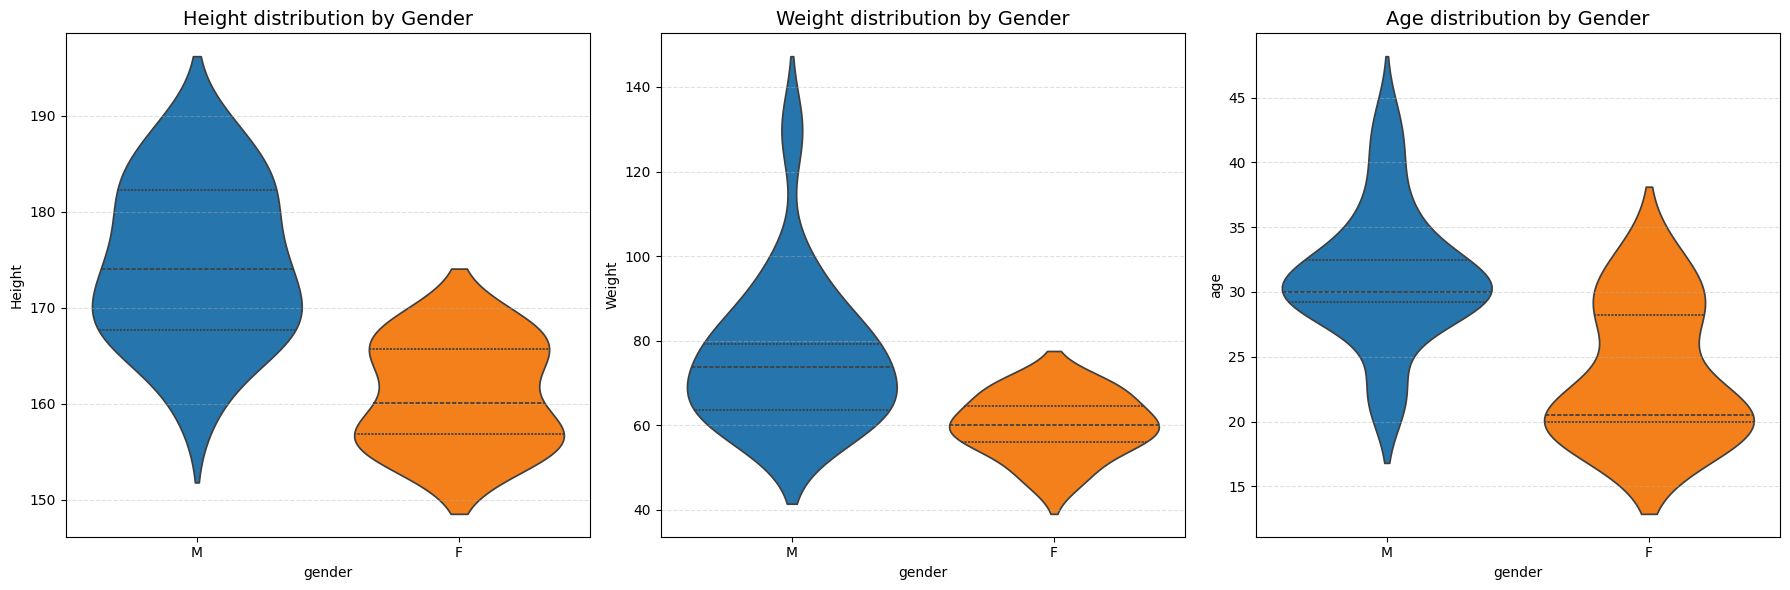

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

features = ['Height', 'Weight', 'age']

for i, feature in enumerate(features):
    sns.violinplot(
        data=metadata, 
        x="gender", 
        y=feature, 
        hue="gender",    
        inner="quartile", 
        bw_adjust=.9, 
        saturation=.9, 
        legend=False,    
        ax=axes[i]       
    )
    
    axes[i].set_title(f"{feature.capitalize()} distribution by Gender", fontsize=14)
    axes[i].grid(True, alpha=0.4, axis="y", linestyle='--')

plt.tight_layout()
plt.show()

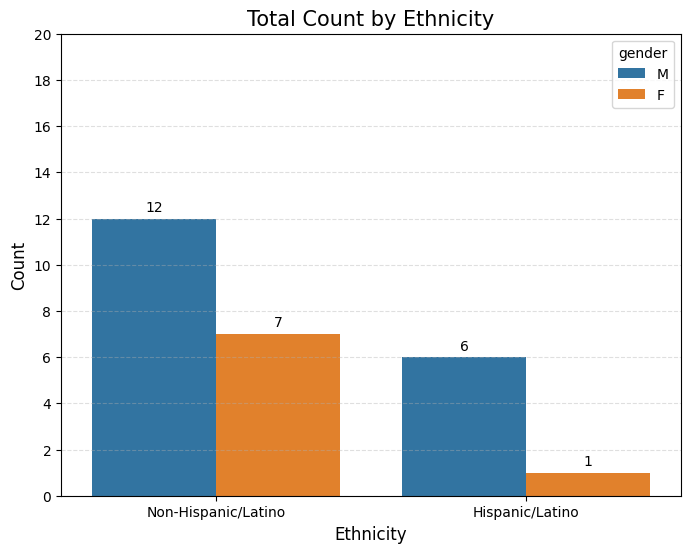

In [6]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=metadata, x='Ethnicity', hue='gender')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='400')

# Adding descriptive labels
plt.title('Total Count by Ethnicity', fontsize=15)
plt.xlabel('Ethnicity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.4, axis="y", linestyle='--')
plt.yticks(range(0, 21, 2))
plt.ylim(0, 20)
plt.show()

In [11]:
import mne

# 1. Load the .set file
# If your .fdt file is in the same folder, MNE will find it automatically
file_path = "D:\Developer\EEG Dataset\ds003670\sub-001\ses-01\eeg\sub-001_ses-01_task-GXtESCTT_eeg.set"
raw = mne.io.read_raw_eeglab(file_path, preload=True)

# 2. Print basic info (sampling rate, channels, duration)
print(raw.info)

# 3. Plot the raw continuous data
# This opens an interactive window
raw.plot(duration=5, n_channels=20, title="Raw EEG Data")

# 4. Visualize Sensor Locations (Topomap)
raw.plot_sensors(show_names=True)

# 5. Plot Power Spectral Density (Frequency Domain)
raw.compute_psd().plot()

ValueError: Unknown mat file type, version 48, 97

In [ ]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)